In [5]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Preprocessing

First, we need to clean up the raw data. In this step, we will:
1. **Drop irrelevant identifiers:** `user_id`, `ad_id`, and `interaction_timestamps` don't help our models.
2. **Keep TF-IDF:** We are leaving the `tfidf` columns untouched because they represent the actual text content of the ads, which is crucial for predicting engagement.
3. **Yeo-Johnson Transformation:** Because the distribution of `clicks` is exponential, we apply Yeo-Johnson transformation to make the distribution more normal. This will allow us to get better results for our SVM model. The Yeo-Johnson distribution is good for exponential distributions and works with 0 and negative values.
4. **Normalization:** Apply Min-Max scaling to the continuous features.
5. **One-Hot Encoding:** Because the numbers assigned to the categorical features are arbitrary, we use one-hot encoding to prevent bias in our models.

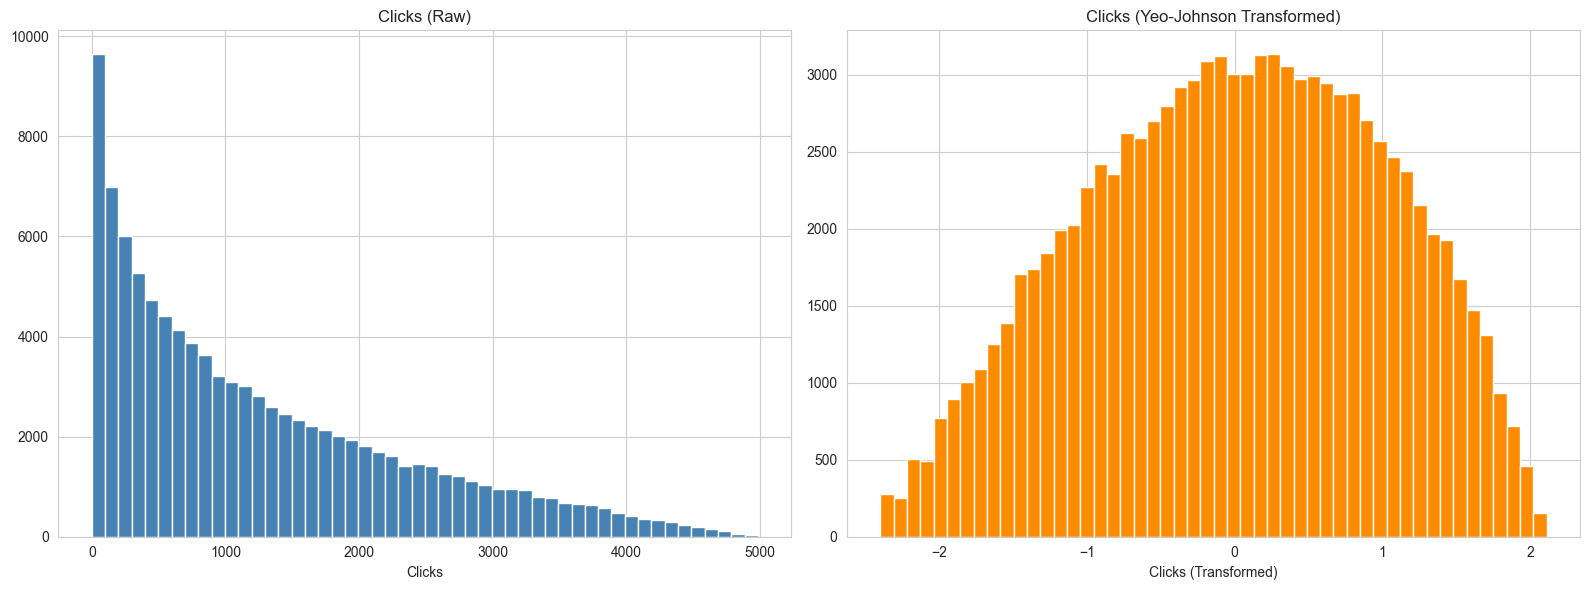

Final dataset shape: (100000, 43)


,age,impressions,clicks,engagement_duration,previous_interaction_score,sentiment_score,tfidf_0,tfidf_1,tfidf_2,tfidf_3,...,location_4,device_type_0,device_type_1,device_type_2,ad_category_0,ad_category_1,ad_category_2,ad_category_3,ad_category_4,conversions
0,0.586957,0.491080,0.245336,95.867210,0.761323,0.626378,0.000000,0.0,0.000000,0.57735,...,0,0,0,1,0,0,1,0,0,1
1,0.239130,0.030467,0.023470,83.940891,0.859277,0.881898,0.447214,0.0,0.447214,0.00000,...,0,0,0,1,0,1,0,0,0,1
2,0.891304,0.729204,0.111133,87.167593,0.773841,0.642324,0.000000,0.0,0.000000,0.00000,...,0,0,0,1,0,1,0,0,0,1
3,0.630435,0.127881,0.051956,74.662671,0.002446,0.924154,0.000000,0.0,0.000000,0.00000,...,0,0,0,1,0,0,0,0,1,1
4,0.391304,0.719182,0.373119,104.902438,0.996080,0.350020,0.000000,0.0,0.000000,0.00000,...,0,1,0,0,0,0,1,0,0,1


In [6]:
# 1. Load the original dataset
df = pd.read_csv('ad_campaign_data.csv')

# 2. Drop unnecessary identifiers and timestamps
columns_to_drop = ['user_id', 'ad_id', 'interaction_timestamps']
df_processed = df.drop(columns=columns_to_drop)

# 3. Yeo-Johnson transformation for SVMs
df_transformed = df.copy()
# Drop columns we're not using
df_transformed.drop(columns=columns_to_drop, inplace=True)
# Apply Yeo-Johnson transformation to clicks to reduce skew
transformer = PowerTransformer(method='yeo-johnson')
df_transformed['clicks'] = transformer.fit_transform(df_transformed[['clicks']])
# Visualize change in distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Clicks before transformation
axes[0].hist(df_processed['clicks'], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Clicks (Raw)")
axes[0].set_xlabel("Clicks")
# Clicks after transformation
axes[1].hist(df_transformed['clicks'], bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Clicks (Yeo-Johnson Transformed)")
axes[1].set_xlabel("Clicks (Transformed)")
plt.tight_layout()
plt.show()

# 4. Normalization
continuous_features = ['age', 'impressions', 'clicks', 'previous_interaction_score', 'sentiment_score']
scaler = MinMaxScaler()
df_processed[continuous_features] = scaler.fit_transform(df_processed[continuous_features])
df_transformed[continuous_features] = scaler.fit_transform(df_transformed[continuous_features]) # for SVMs

# 5. One-Hot Encoding
encode_vars = ['gender', 'location', 'device_type', 'ad_category']
df_encoded = pd.get_dummies(df_processed, columns=encode_vars, prefix=encode_vars, dtype=int)
# For SVM model (with transformed clicks)
df_encoded_svm = pd.get_dummies(df_transformed, columns=encode_vars, prefix=encode_vars, dtype=int)

# 6. Move the target variable ('conversions') to the end
encoded_feature_cols = [col for col in df_encoded.columns if col != 'conversions']
df_encoded = df_encoded[encoded_feature_cols + ['conversions']]
df_encoded_svm = df_encoded_svm[encoded_feature_cols + ['conversions']]

# 7. Save to a clean CSV for the team to use
output_filename = 'final_project_data.csv'
df_encoded.to_csv(output_filename, index=False)
df_encoded_svm.to_csv('svm_project_data.csv', index=False)

print(f"Final dataset shape: {df_encoded.shape}")
df_encoded.head()

## Exploratory Data Analysis (EDA)
Let's visualize the distributions of our continuous and categorical features to understand the shape of our data before feeding it into our models.

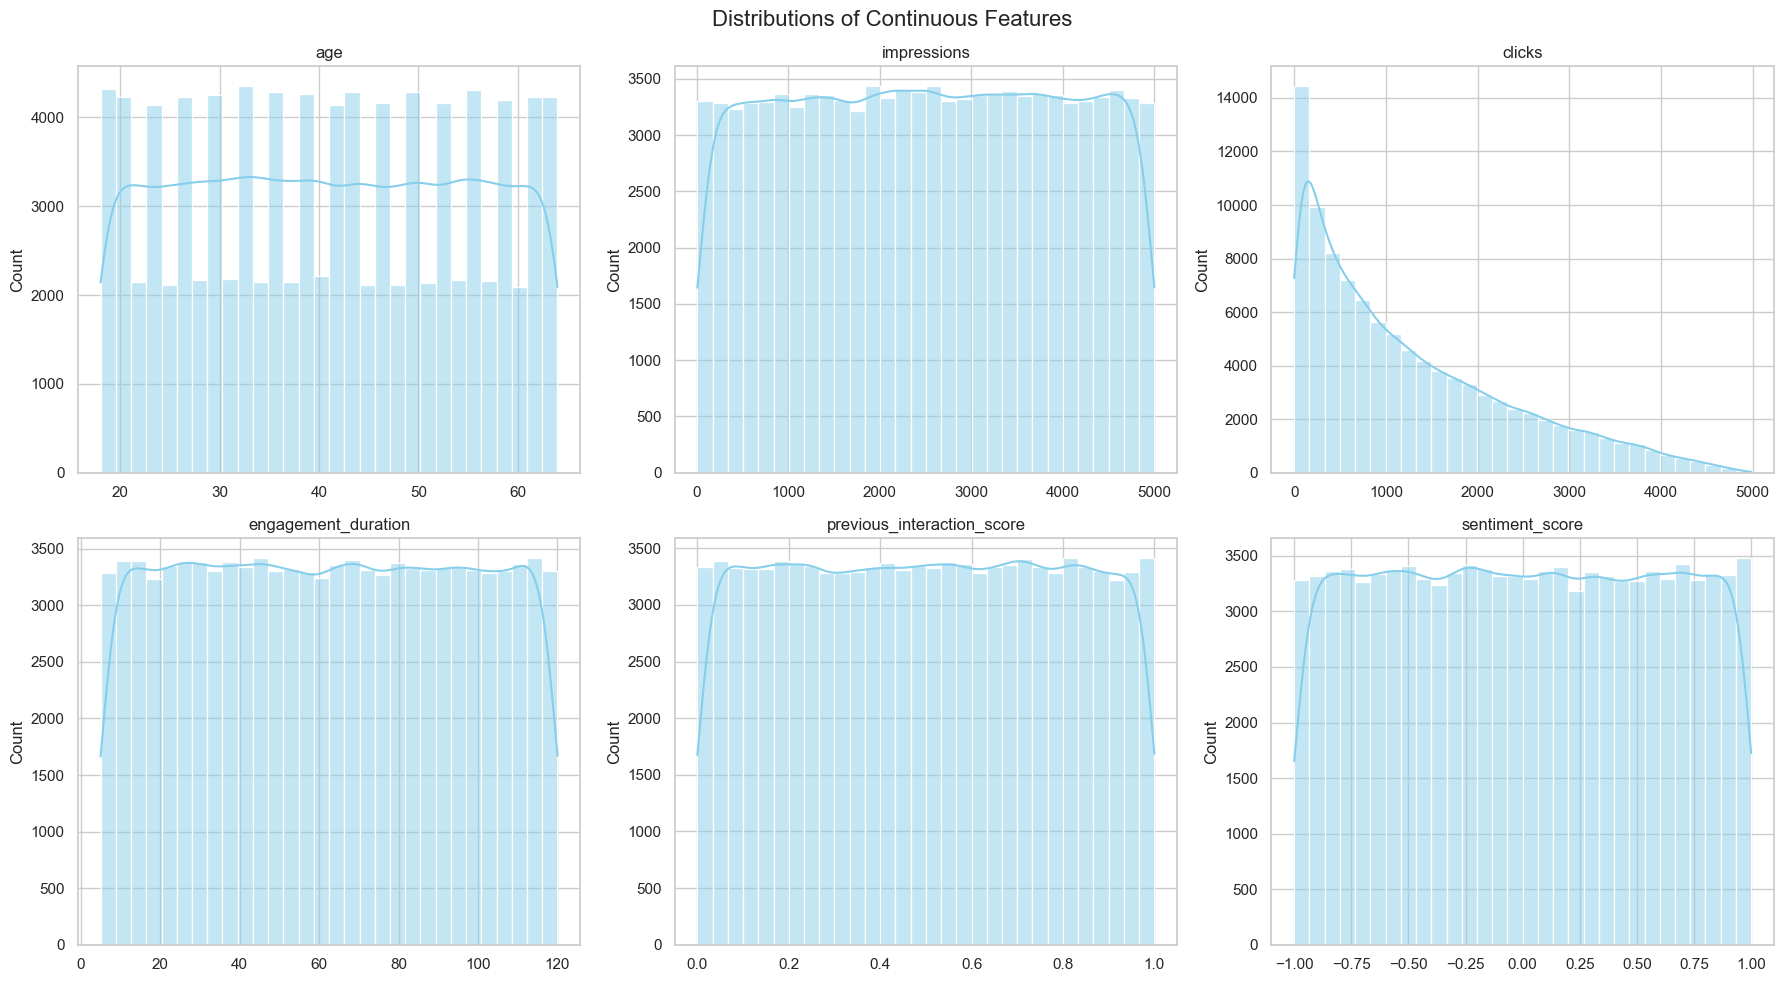

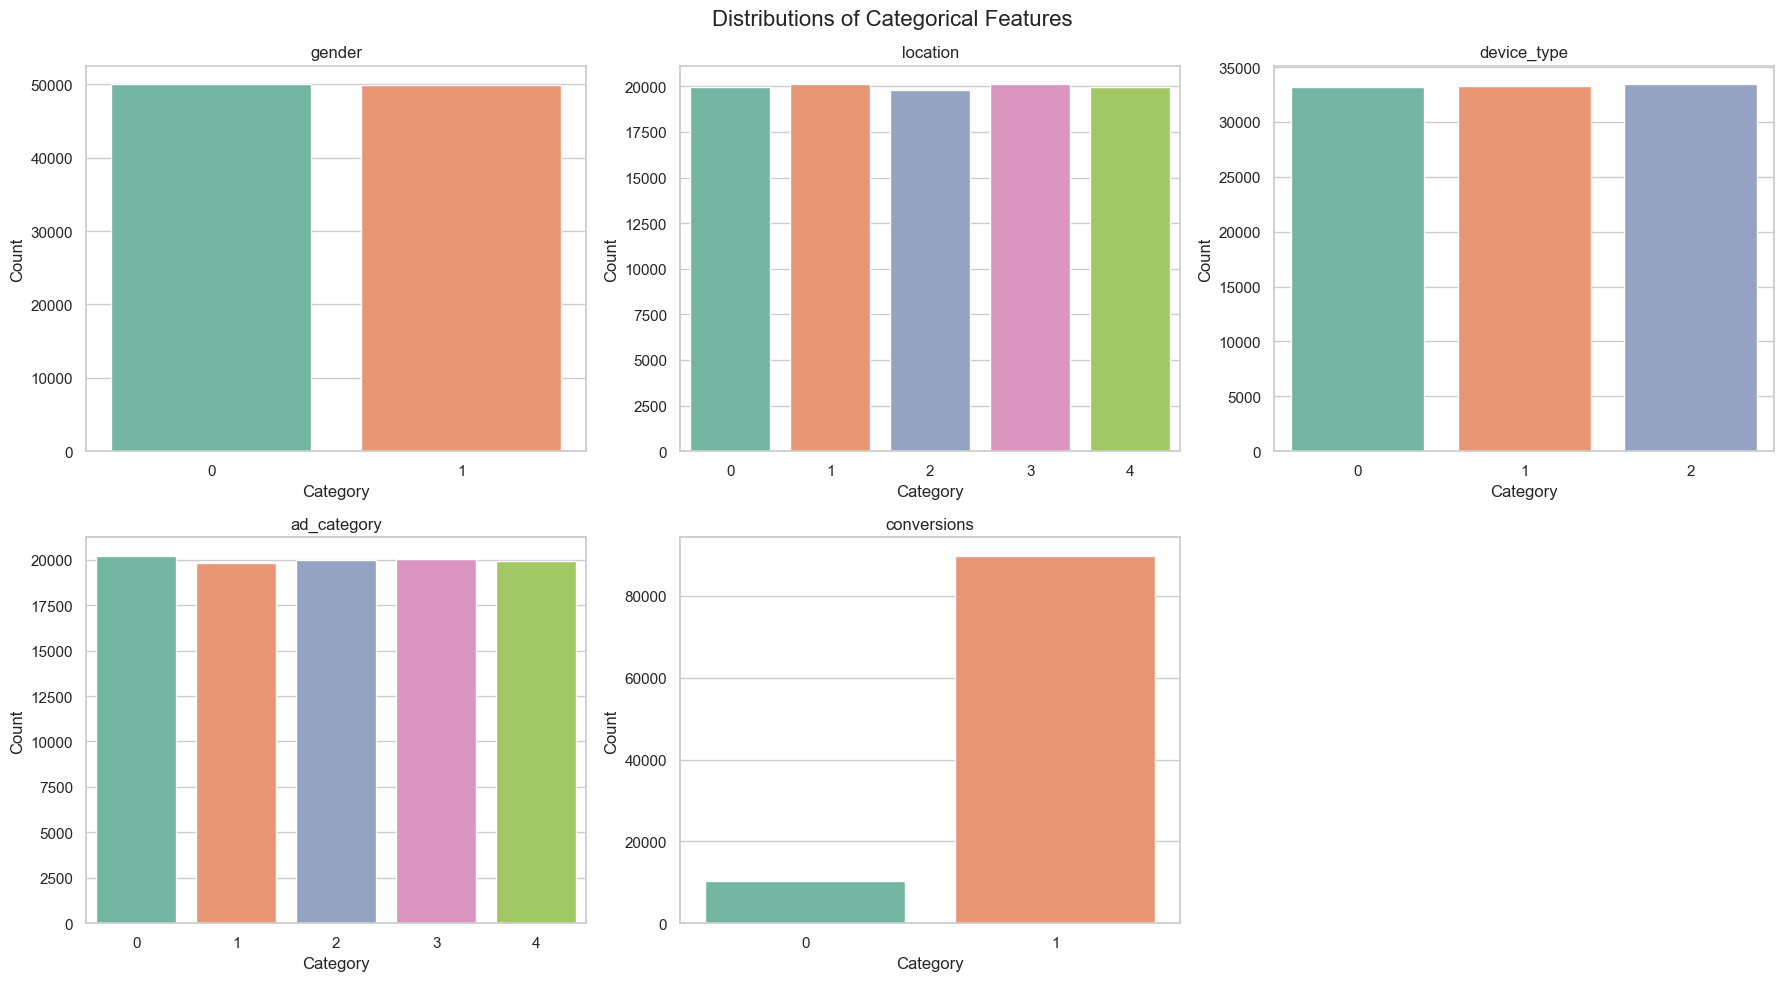

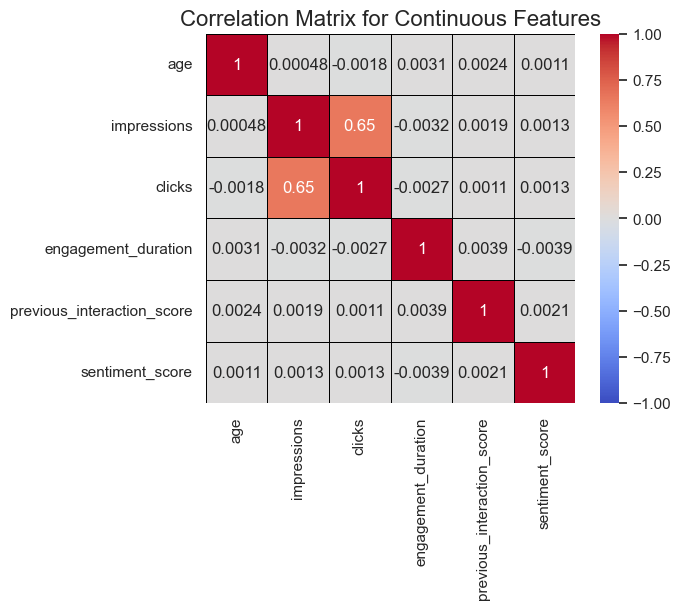

KeyboardInterrupt: 

In [ ]:
# Set up the visual style
sns.set_theme(style="whitegrid")

# Define our feature groups
continuous_features = ['age', 'impressions', 'clicks', 'engagement_duration', 'previous_interaction_score', 'sentiment_score']
categorical_features = ['gender', 'location', 'device_type', 'ad_category', 'conversions']

# --- Plot 1: Continuous Distributions ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Continuous Features', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# --- Plot 2: Categorical Distributions ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Categorical Features', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    val_counts = df[col].value_counts().sort_index()
    sns.barplot(x=val_counts.index, y=val_counts.values, hue=val_counts.index, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')

axes[5].set_visible(False) # Hide the last empty subplot
plt.tight_layout()
plt.show()

# --- Plot 3: Correlation Matrix for Continuous Features ---
continuous_df = df_processed[continuous_features] # dataframe with continuous features
sns.heatmap(continuous_df.corr(), annot=True, vmin=-1, vmax=1, center=0, cmap='coolwarm', linewidths=0.5, linecolor='black', square=True)
plt.title('Correlation Matrix for Continuous Features', fontsize=16)
plt.show()

# --- Plot 4: Pairplot ---
pairplot_features = continuous_features
pairplot_features.append('conversions')
pairplot_df = df_processed[pairplot_features]
sns.set_style('whitegrid')
sns.pairplot(pairplot_df, hue='conversions')
plt.show()